# Historic / Future Model Runs

Let us do some research now, with help of the [CMIP6 dataset](https://pcmdi.llnl.gov/CMIP6/).
We will look how our model fares with historical CMIP data and their climate models that predict future scenarios.
I have setup some possible climate change models for you to use, you have to fill in your camel ID and think of a research question!

We like the sentence:
- To understand [environment issue] in [region] we will study te impact of [verb/noun] on [hydrological variable].

But feel free to come up with your own!
Some hints:
- Maybe look at a smaller time period.
- What do certain climate changes do to your region.

## In This Notebook: Model runs with CMIP Forcing

In this notebook we will do the model runs for the chosen areas with the generated forcing from the previous notebook.
This will be used to do our research with!

## Importing and setting up

In [1]:
# Ignore user warnings :)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Required dependencies
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
from rich import print
import xarray as xr
import shutil
import json

import ewatercycle
import ewatercycle.models

from util_functions import *

You can change the folder structure as well, but note that you will have to change that in upcoming notebooks as well!

In [2]:
# Load settings
# Read from the JSON file
with open("settings.json", "r") as json_file:
   settings = json.load(json_file)

camel_id = settings["caravan_id"]

In [3]:
historical_start = settings["calibration_start_date"]
historical_end = settings["calibration_end_date"]

future_start_data = settings["future_start_date"]
future_end_data = settings["future_end_date"]

## Loading in the CMIP forcings

In [4]:
# Load the generated historical data
historical_location = Path(settings["path_CMIP6"]) / "historical" / "work" / "diagnostic" / "script" 
historical = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=historical_location)

# Load the generated SSP126 data
ssp126_location = Path(settings["path_CMIP6"]) / "SSP126" / "work" / "diagnostic" / "script" 
SSP126 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp126_location)

# Load the generated SSP245 data
ssp245_location = Path(settings["path_CMIP6"]) / "SSP245" / "work" / "diagnostic" / "script" 
SSP245 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp245_location)

# Load the generated SSP585 data
ssp585_location = Path(settings["path_CMIP6"]) / "SSP585" / "work" / "diagnostic" / "script" 
SSP585 = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=ssp585_location)

# This additional steo is needed because ERA5 forcing data is stored deep in a sub-directory
era5_location = Path(settings['path_ERA5']) / "work" / "diagnostic" / "script" 
ERA5_forcing_object = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=era5_location)

In [5]:
print(settings)

{
    'caravan_id': 'hysets_02OJ024',
    'calibration_start_date': '1985-08-01T00:00:00Z',
    'calibration_end_date': '1995-07-31T00:00:00Z',
    'future_start_date': '2029-08-01T00:00:00Z',
    'future_end_date': '2049-07-31T00:00:00Z',
    'base_path': '/home/mmelotto/my_data/workshop_canada',
    'path_caravan': '/home/mmelotto/my_data/workshop_canada/forcing_data/hysets_02OJ024/caravan',
    'path_shape': '/home/mmelotto/my_data/workshop_canada/forcing_data/hysets_02OJ024/caravan/hysets_02OJ024.shp',
    'path_ERA5': '/home/mmelotto/my_data/workshop_canada/forcing_data/hysets_02OJ024/ERA5',
    'path_CMIP6': '/home/mmelotto/my_data/workshop_canada/forcing_data/hysets_02OJ024/CMIP6',
    'path_output': '/home/mmelotto/my_data/workshop_canada/output_data/hysets_02OJ024',
    'hbv_parameters_manual': [8.0, 0.922, 43.075, 0.703, 0.001, 1.018, 0.1, 0.006, 3.244]
}

Using the parameters we found earlier:
- hbv_parameters: the one you found manually
- monte_carlo_calibration_parameters: parameters based on monte carlo (If you ran this)
- SCE_calibration_parameters: parameters based on SCE (If you ran this)

In [6]:
parameters_found = settings["hbv_parameters_manual"]  

#               Si,  Su, Sf, Ss, Sp
s_0 = np.array([0,  100,  0,  5,  0])

## Setting up the models

I took this bit from our Bachelor student Ischa, so thank you very much!
We put the forcings in a list and then we will use that to look through the models we created, using the BMI implementation.
NOTE: we use ```HBVLocal``` here to speed up the process. This is a model that just runs locally, without the setup of containers, which is proportionally heavier than the running of the actual model.

In [7]:
forcing_list_historic =  [historical, ERA5_forcing_object]
name_list = ["historical CMIP", "ERA5"]
output_historic = []
years = []

# Create model object, notice the forcing object.
model_output_historic = dict()

for idx, forcings in enumerate(forcing_list_historic):
    model = ewatercycle.models.HBVLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=parameters_found, 
        initial_storage=s_0,
        # cfg_dir = settings[""],
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output_historic.append(Q_m)
    years.append(time)
    model_output_historic[f"{name_list[idx]}"] = pd.Series(data=Q_m, name="modelled discharge, forcing: " + f"{name_list[idx]}", index=time)
    model.finalize()

In [8]:
forcing_list_future = [SSP126, SSP245, SSP585]
name_list = ["SSP126", "SSP245", "SSP585"]
output_future = []
years_future = []

# Create model object, notice the forcing object.
model_output_future=dict()

for idx, forcings in enumerate(forcing_list_future):
    model = ewatercycle.models.HBVLocal(forcing=forcings)
    config_file, _ = model.setup(
        parameters=parameters_found, 
        initial_storage=s_0,
        # cfg_dir = settings[""],
    )

    model.initialize(config_file)

    Q_m = []
    time = []
    
    while model.time < model.end_time:
        model.update()
        Q_m.append(model.get_value("Q")[0])
        time.append(pd.Timestamp(model.time_as_datetime))
        
    output_future.append(Q_m)
    years_future.append(time)
    model_output_future[f"{name_list[idx]}"] = pd.Series(data=Q_m, name="modelled discharge, forcing: " + f"{name_list[idx]}", index=time)
    model.finalize()

## Checking our results
Finally, we look at the output and we use standard python libraries to visualize the results. We put the model output into a pandas Series to make plotting easier.

In [9]:
SSP126_output = pd.Series(data=output_future[0], name="SSP126", index=years_future[0])
SSP245_output = pd.Series(data=output_future[1], name="SSP245", index=years_future[1])
SSP585_output = pd.Series(data=output_future[2], name="SSP585", index=years_future[2])
historical_output = pd.Series(data=output_historic[0], name="Historical", index=years[0])

Looking at the historical data modelling first.

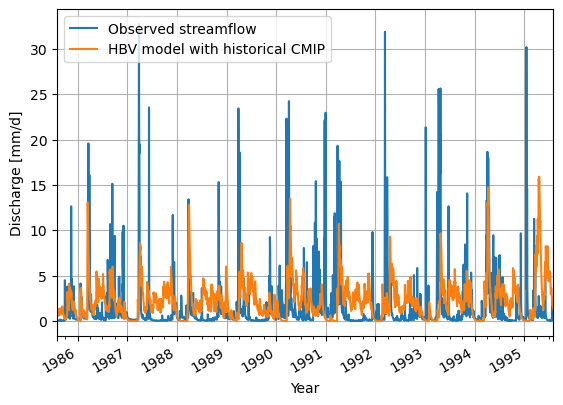

In [10]:
caravan_data_object = ewatercycle.forcing.sources['CaravanForcing'].load(directory=settings['path_caravan']) # Create a dataframe for the observations
ds_observation = xr.open_mfdataset([caravan_data_object['Q']]).to_pandas()
ds_observation = ds_observation['Q']


ds_observation.plot(label="Observed streamflow")
historical_output.plot(label="HBV model with historical CMIP")

plt.legend()
plt.grid()
plt.ylabel("Discharge [mm/d]")
plt.xlabel("Year")
plt.show()

Now for the visualising you will look at the model outputs, which is, as you will see, pointless for this many years.

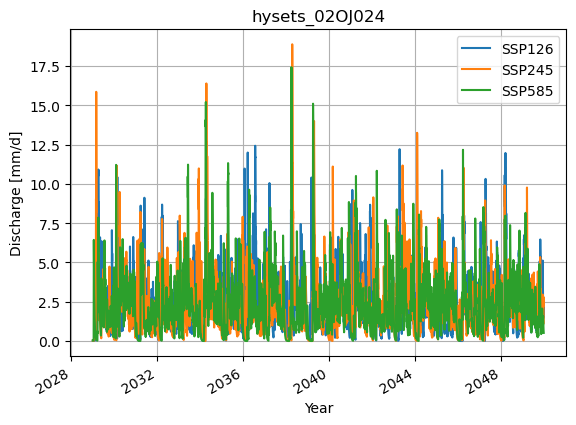

In [11]:
SSP126_output.plot()
SSP245_output.plot()
SSP585_output.plot()

plt.legend()
plt.grid()
plt.title(f"{settings["caravan_id"]}")
plt.ylabel("Discharge [mm/d]")
plt.xlabel("Year")
plt.show()

## Done with the model runs

Now go to the next Notebook to do some research!

But first let us save all the results (including ERA5):

In [12]:
caravan_data_object = caravan_data_object

In [13]:
caravan_discharge_observation = xr.open_mfdataset([caravan_data_object['Q']])
caravan_discharge_observation = caravan_discharge_observation.rename_vars({'Q':'Observed Discharge Caravan'})

In [14]:
# We want to also be able to use the output of this model run in different analyses. Therefore, we save it as a NetCDF file.
xr_model_output_historic = xr.merge([model_output_per_model.to_xarray() for name, model_output_per_model in model_output_historic.items()])
xr_model_output_historic = xr_model_output_historic.rename({'index': 'time'})
xr_model_output_historic.attrs['units'] = 'mm/d'
print(xr_model_output_historic)

<xarray.Dataset> Size: 96kB
Dimensions:                                       (time: 4016)
Coordinates:
  * time                                          (time) datetime64[ns] 32kB ...
Data variables:
    modelled discharge, forcing: historical CMIP  (time) float64 32kB 0.03001...
    modelled discharge, forcing: ERA5             (time) float64 32kB 0.03001...
Attributes:
    units:    mm/d

In [15]:
# Saving the data for the next Notebook
# Interpolate model data to match the timestamps of the observations
xr_model_output_interp = xr_model_output_historic.interp(time=caravan_discharge_observation.time)

# Merge the interpolated model output with observations
xr_merged_historic = xr.merge([xr_model_output_interp, caravan_discharge_observation[['Observed Discharge Caravan']]])

print(xr_merged_historic)

<xarray.Dataset> Size: 103kB
Dimensions:                                       (time: 3652)
Coordinates: (12/18)
  * time                                          (time) datetime64[ns] 29kB ...
    basin_id                                      <U14 56B 'hysets_02OJ024'
    timezone                                      <U15 60B 'America/Toronto'
    name                                          <U54 216B 'HURONS (RIVIERE ...
    country                                       <U6 24B 'Canada'
    lat                                           float64 8B 45.49
    ...                                            ...
    moisture_index                                float64 8B -0.006737
    seasonality                                   float64 8B 1.298
    high_prec_freq                                float64 8B 0.0497
    high_prec_dur                                 float64 8B 1.102
    low_prec_freq                                 float64 8B 0.5889
    low_prec_dur                                  float64 8B 2.842
Data variables:
    modelled discharge, forcing: historical CMIP  (time) float64 29kB 0.919 ....
    modelled discharge, forcing: ERA5             (time) float64 29kB 1.005 ....
    Observed Discharge Caravan                    (time) float32 15kB dask.array<chunksize=(3652,), 
meta=np.ndarray>
Attributes:
    units:    mm/d

In [16]:
# Save the xarray Dataset to a NetCDF file
xr_merged_historic.to_netcdf(Path(settings['path_output']) / (settings['caravan_id'] + '_historic_output.nc'))

We will save the CMIP runs separately. 

In [17]:
xr_model_output_future = xr.merge([model_output_per_model.to_xarray() for name, model_output_per_model in model_output_future.items()])
xr_model_output_future = xr_model_output_future.rename({'index': 'time'})
xr_model_output_future.attrs['units'] = 'mm/d'

In [18]:
# Save the xarray Dataset to a NetCDF file
xr_model_output_future.to_netcdf(Path(settings['path_output']) / (settings['caravan_id'] + '_future_output.nc'))

In [19]:
# Remove all temporary directories made by the optimization algo.

!rm -rf hbvlocal_*